In [13]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import matplotlib.pyplot as plt

In [2]:
TRAIN_START = "2020-01-01"
TRAIN_END = "2025-06-30"

TEST_START = "2025-07-01"
TEST_END = "2026-06-30"

TRAIN = pd.date_range(start=TRAIN_START, end=TRAIN_END)
TEST = pd.date_range(start=TEST_START, end=TEST_END)

In [3]:
# Remove SHIB-USD since it has inf value
ticker_universe = ["BTC-USD", "ETH-USD", "BNB-USD", "XRP-USD", "SOL-USD", "TRX-USD", "ZEC-USD", "DOGE-USD", "XMR-USD", "LINK-USD", "ADA-USD", "XLM-USD", "BCH-USD", "LTC-USD", "NEAR-USD", "AVAX-USD", "HBAR-USD", "KCS-USD", "ALGO-USD", "DASH-USD"]

In [4]:
daily_prices = yf.download(tickers=ticker_universe, period="max", interval="1d")

[*********************100%***********************]  20 of 20 completed


In [5]:
daily_returns = daily_prices["Close"].pct_change(fill_method=None)
daily_volumes = daily_prices["Volume"]

In [6]:
weight_lag = 2

In [199]:
def featureX(ticker="BTC-USD"):
    df = pd.DataFrame()
    
    df["7_AVG"] = daily_returns.shift().rolling(7).mean()[ticker]
    df["28_AVG"] = daily_returns.shift().rolling(28).mean()[ticker]
    df["60_AVG"] = daily_returns.shift().rolling(60).mean()[ticker]
    df["28_VOL_RATIO"] = (daily_volumes.shift() / daily_volumes.shift().rolling(28).mean())[ticker]
    df["60_VOL_RATIO"] = (daily_volumes.shift() / daily_volumes.shift().rolling(60).mean())[ticker]
    df["28_AVG_VS_BTC"] = daily_returns.shift().rolling(28).mean()[ticker] - daily_returns.shift().rolling(28).mean()["BTC-USD"]
    df["28_AVG_VS_ETH"] = daily_returns.shift().rolling(28).mean()[ticker] - daily_returns.shift().rolling(28).mean()["ETH-USD"]
    df["28_STD"] = daily_returns.shift().rolling(28).std()[ticker]
    df["60_STD"] = daily_returns.shift().rolling(60).std()[ticker]
    df["INV_28_STD"] = 1 / daily_returns.shift().rolling(28).std()[ticker]
    df["INV_60_STD"] = 1 / daily_returns.shift().rolling(60).std()[ticker]

    # return df.iloc[:-weight_lag][::weight_lag]
    return df

feature_x = featureX()
feature_x

,7_AVG,28_AVG,60_AVG,28_VOL_RATIO,60_VOL_RATIO,28_AVG_VS_BTC,28_AVG_VS_ETH,28_STD,60_STD,INV_28_STD,INV_60_STD
Date,,,,,,,,,,,
2014-09-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2026-09-27,0.005819,0.002955,0.004904,0.506377,0.527246,0.0,-0.000627,0.022797,0.022693,43.865490,44.065522
2026-09-28,0.006066,0.003241,0.004904,0.647101,0.677447,0.0,-0.000809,0.022712,0.022693,44.028669,44.065744
2026-09-29,-0.005163,0.002432,0.004503,1.401553,1.474206,0.0,-0.000919,0.022816,0.022765,43.828019,43.927747


In [200]:
def featureY(ticker="BTC-USD"):
    # return daily_returns[ticker][::-1].rolling(window=weight_lag).sum()[::-1].iloc[:-weight_lag][::weight_lag]
    return daily_returns[ticker][::-1].rolling(window=weight_lag).sum()[::-1]

feature_y = featureY()
feature_y

Date
2014-09-17         NaN
2014-09-18   -0.141768
2014-09-19   -0.034108
2014-09-20    0.011076
2014-09-21   -0.016306
                ...   
2026-09-27   -0.010701
2026-09-28   -0.009878
2026-09-29    0.000615
2026-09-30   -0.002191
2026-10-01         NaN
Freq: D, Name: BTC-USD, Length: 4398, dtype: float64

In [201]:
pd.concat({
    "featureX": feature_x,
    "featureY": feature_y
}, axis=1).dropna()

featureX                                                \
               7_AVG    28_AVG    60_AVG 28_VOL_RATIO 60_VOL_RATIO   
Date                                                                 
2017-12-08  0.086784  0.035486  0.024280     2.890699     4.283977   
2017-12-09  0.065809  0.035459  0.022457     3.118020     4.686838   
2017-12-10  0.052526  0.033866  0.021023     1.959288     2.950506   
2017-12-11  0.051928  0.036808  0.021172     1.850307     2.731232   
2017-12-12  0.061407  0.036573  0.020627     1.626937     2.395121   
...              ...       ...       ...          ...          ...   
2026-09-26  0.005774  0.002988  0.004868     1.140450     1.179747   
2026-09-27  0.005819  0.002955  0.004904     0.506377     0.527246   
2026-09-28  0.006066  0.003241  0.004904     0.647101     0.677447   
2026-09-29 -0.005163  0.002432  0.004503     1.401553     1.474206   
2026-09-30 -0.004248  0.003004  0.005019     0.925230     0.971593   

                                                                       \
           28_AVG_VS_BTC 28_AVG_VS_ETH    28_STD    60_STD INV_28_STD   
Date                                                                    
2017-12-08           0.0      0.023428  0.069474  0.055603  14.393836   
2017-12-09           0.0      0.019215  0.069519  0.057019  14.384595   
2017-12-10           0.0      0.018095  0.071771  0.058600  13.933222   
2017-12-11           0.0      0.022665  0.069251  0.058581  14.440319   
2017-12-12           0.0      0.017517  0.069031  0.057711  14.486309   
...                  ...           ...       ...       ...        ...   
2026-09-26           0.0     -0.000752  0.022800  0.022696  43.860016   
2026-09-27           0.0     -0.000627  0.022797  0.022693  43.865490   
2026-09-28           0.0     -0.000809  0.022712  0.022693  44.028669   
2026-09-29           0.0     -0.000919  0.022816  0.022765  43.828019   
2026-09-30           0.0     -0.000898  0.022574  0.022327  44.299270   

                       featureY  
           INV_60_STD   BTC-USD  
Date                             
2017-12-08  17.984594 -0.158282  
2017-12-09  17.538068 -0.065699  
2017-12-10  17.064816  0.114113  
2017-12-11  17.070338  0.124108  
2017-12-12  17.327725 -0.029576  
...               ...       ...  
2026-09-26  44.060824  0.005033  
2026-09-27  44.065522 -0.010701  
2026-09-28  44.065744 -0.009878  
2026-09-29  43.927747  0.000615  
2026-09-30  44.789349 -0.002191  

[3219 rows x 12 columns]

In [214]:
def Regression(ticker="BTC-USD"):
    X = featureX(ticker).dropna()
    Y = featureY(ticker).dropna()
    
    common_index = X.index.intersection(Y.index)
    regression_model = RollingOLS(Y.loc[common_index], sm.add_constant(X.loc[common_index]), window=90).fit()
    return regression_model

regression_parameters = {
    ticker: Regression(ticker).params.shift().dropna() for ticker in ticker_universe
}

In [215]:
((sm.add_constant(featureX("SOL-USD")) * regression_parameters["SOL-USD"]).sum(axis=1)).dropna()

Date
2014-09-17    0.000000
2014-09-18    0.000000
2014-09-19    0.000000
2014-09-20    0.000000
2014-09-21    0.000000
                ...   
2026-09-27    0.048496
2026-09-28    0.009000
2026-09-29    0.001264
2026-09-30   -0.016562
2026-10-01    0.000000
Freq: D, Length: 4398, dtype: float64

In [220]:
def momentumWeights(DATE_RANGE=TRAIN):
    signal = pd.DataFrame({
        ticker: (sm.add_constant(featureX(ticker)) * regression_parameters[ticker]).sum(axis=1) for ticker in ticker_universe
    })
    ranked = signal.rank(axis=1)
    demeaned =  ranked.sub(ranked.mean(axis=1), axis=0)
    weights = demeaned.div(demeaned.abs().sum(axis=1), axis=0)
    lagged_weights = weights.iloc[::weight_lag].reindex(weights.index, method="ffill")
    return lagged_weights

momentum_weights = momentumWeights()
momentum_weights.dropna()

,BTC-USD,ETH-USD,BNB-USD,XRP-USD,SOL-USD,TRX-USD,ZEC-USD,DOGE-USD,XMR-USD,LINK-USD,ADA-USD,XLM-USD,BCH-USD,LTC-USD,NEAR-USD,AVAX-USD,HBAR-USD,KCS-USD,ALGO-USD,DASH-USD
Date,,,,,,,,,,,,,,,,,,,,
2018-03-08,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,-0.500,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316
2018-03-09,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316,-0.500,0.026316,0.026316,0.026316,0.026316,0.026316,0.026316
2018-03-10,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,0.500,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316
2018-03-11,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,0.500,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316
2018-03-12,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,0.500,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316,-0.026316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-27,-0.010000,-0.010000,0.025000,-0.095000,0.065000,0.005000,0.075000,0.035000,0.045000,0.055000,-0.075000,-0.025000,-0.045000,0.085,0.095000,-0.085000,-0.065000,-0.055000,0.015000,-0.035000
2026-09-28,-0.010000,-0.010000,0.045000,-0.085000,0.035000,0.015000,0.085000,-0.035000,0.055000,0.075000,-0.095000,0.005000,-0.065000,-0.075,0.095000,0.025000,0.065000,-0.045000,-0.025000,-0.055000
2026-09-29,-0.010000,-0.010000,0.045000,-0.085000,0.035000,0.015000,0.085000,-0.035000,0.055000,0.075000,-0.095000,0.005000,-0.065000,-0.075,0.095000,0.025000,0.065000,-0.045000,-0.025000,-0.055000


In [221]:
def netMomentum(momentum_weights):
    return (momentum_weights * daily_returns).subtract((momentum_weights - momentum_weights.shift()).abs() * 0.002, fill_value=0).sum(axis=1)

net_momentum = netMomentum(momentum_weights)
net_momentum.describe()

count    4398.000000
mean        0.001572
std         0.010510
min        -0.140794
25%        -0.001756
50%         0.000000
75%         0.004391
max         0.130317
dtype: float64

In [222]:
def sharpeRatio(x):
    return x.mean() / x.std() * np.sqrt(252)

<Axes: title={'center': 'Train Momentum Strategy Sharpe (Overall 2.60)'}>

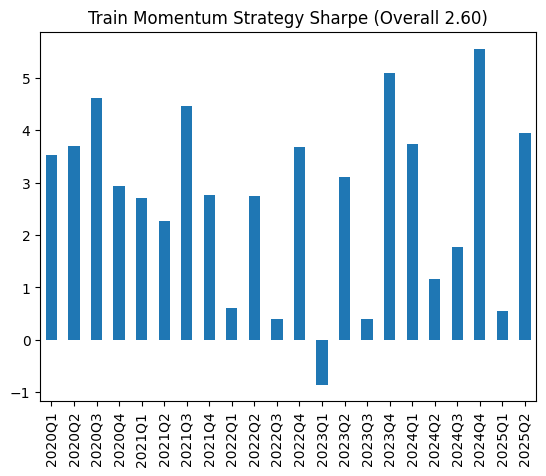

In [229]:
net_momentum[TRAIN].resample("QE").apply(sharpeRatio).to_period("Q").plot(kind="bar", title=f"Train Momentum Strategy Sharpe (Overall {sharpeRatio(net_momentum[TRAIN]):.2f})")

<Axes: title={'center': 'Test Momentum Strategy Sharpe (Overall 2.67)'}>

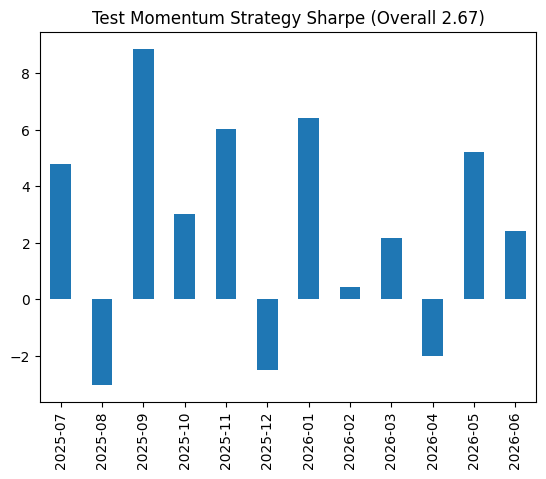

In [228]:
net_momentum[TEST].resample("ME").apply(sharpeRatio).to_period("M").plot(kind="bar", title=f"Test Momentum Strategy Sharpe (Overall {sharpeRatio(net_momentum[TEST]):.2f})")

<Axes: title={'center': 'Train Momentum Drawdown'}>

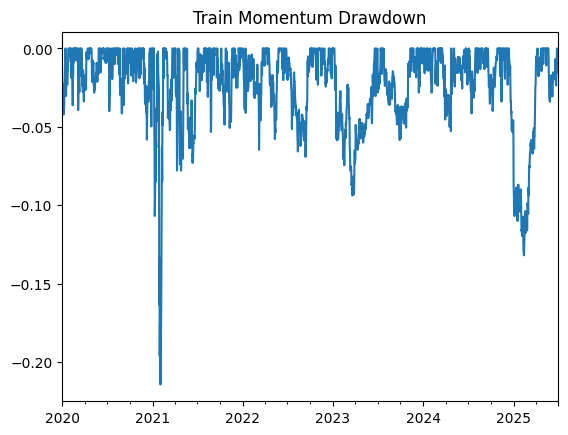

In [237]:
drawdown = (1 + net_momentum).cumprod() / (1 + net_momentum).cumprod().cummax() - 1
drawdown[TRAIN].plot(title="Train Momentum Drawdown")

<Axes: title={'center': 'Test Momentum Drawdown'}>

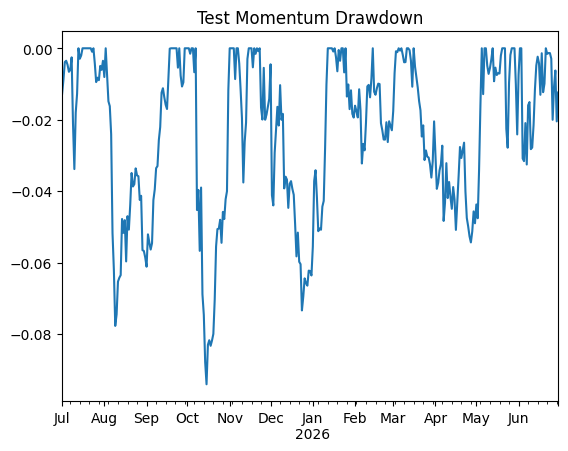

In [236]:
drawdown[TEST].plot(title="Test Momentum Drawdown")